Dataset -> Balanced, Imbalanced

Balanced Dataset: Category (50%-50%)

Imbalanced Dataset: Category (90%-10%)

In [ ]:
#Upsampling - Increasing the number of instances in the minority class
#Downsampling - Decreasing the number of instances in the majority class

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
n_class_0 = 900
n_class_1 = 100

In [ ]:
class_0 = pd.DataFrame({'feature_1': np.random.normal(0,1,900),#Center,s.d., Size
                        'feature_2': np.random.normal(0,1,900),
                        'target': np.zeros(900)})
class_0


,feature_1,feature_2,target
0,-0.963768,-1.144075,0.0
1,-0.329738,-1.821221,0.0
2,-0.331980,-2.034028,0.0
3,0.506512,-0.363930,0.0
4,-0.843911,0.567580,0.0
...,...,...,...
895,-0.064628,-0.830437,0.0
896,-0.100007,-0.817699,0.0
897,-0.776490,-1.031486,0.0
898,2.146095,-0.532772,0.0


In [ ]:
class_1 = pd.DataFrame({'feature_1': np.random.normal(1,1,100),
                        'feature_2': np.random.normal(1,1,100),
                        'target': np.ones(100)})
class_1

,feature_1,feature_2,target
0,-0.008850,1.280861,1.0
1,1.301905,1.469384,1.0
2,0.805317,1.569271,1.0
3,0.628357,1.536701,1.0
4,1.001328,0.553802,1.0
...,...,...,...
95,1.169803,3.147367,1.0
96,3.862308,2.063643,1.0
97,1.384245,2.420946,1.0
98,0.286561,0.191955,1.0


In [ ]:
class_0.shape , class_1.shape

((900, 3), (100, 3))

In [ ]:
df = pd.concat([class_0,class_1]).reset_index(drop=True)
df

,feature_1,feature_2,target
0,-0.963768,-1.144075,0.0
1,-0.329738,-1.821221,0.0
2,-0.331980,-2.034028,0.0
3,0.506512,-0.363930,0.0
4,-0.843911,0.567580,0.0
...,...,...,...
995,1.169803,3.147367,1.0
996,3.862308,2.063643,1.0
997,1.384245,2.420946,1.0
998,0.286561,0.191955,1.0


In [ ]:
df['target'].value_counts()

target
0.0    900
1.0    100
Name: count, dtype: int64

Unsampling

In [ ]:
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]
df_majority.shape,df_minority.shape

((900, 3), (100, 3))

In [ ]:
from sklearn.utils import resample
df_minority_upsampled  = resample(df_minority,replace=True, n_samples=len(df_majority))
df_minority_upsampled #duplicates Data to same size

,feature_1,feature_2,target
947,1.244412,0.376792,1.0
981,0.969258,0.768690,1.0
935,1.274814,2.195318,1.0
928,1.617807,-0.470622,1.0
947,1.244412,0.376792,1.0
...,...,...,...
907,0.916364,0.682457,1.0
962,0.707566,0.491242,1.0
986,2.277162,1.366053,1.0
911,0.660435,2.465528,1.0


In [ ]:
df_minority_upsampled.duplicated().sum()

np.int64(800)

In [ ]:
#Downsampling
df_majority_downsampled = resample(df_majority, replace = False,n_samples=len(df_minority))
df_majority_downsampled

,feature_1,feature_2,target
483,0.565551,-0.120194,0.0
454,1.160281,0.864287,0.0
724,-0.393963,1.268313,0.0
851,-1.366115,0.201777,0.0
201,0.736005,-0.112731,0.0
...,...,...,...
510,0.707432,0.061432,0.0
861,-0.977170,0.056615,0.0
794,0.325475,-0.172109,0.0
545,0.233348,-1.073792,0.0


### Smote

Smote - SMOTE (Synthetic Minority Over-sampling Technique) is a data preprocessing algorithm used to solve the problem of class imbalance in machine learning datasets. 

Data interpolation - It is a mathematical and statistical method used to estimate unknown values that fall between existing known data points. It is used to fill in missing gaps, smooth out datasets, and construct continuous information from sparse or irregular raw measurements.

In [ ]:
from sklearn.datasets import make_classification #generating Synthetic Data
x,y = make_classification(n_samples=1000,n_features=2, n_redundant=0,n_clusters_per_class=1,weights=[0.90],random_state=42)

In [ ]:
x

array([[ 1.0735459 , -1.10133925],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       ...,
       [-2.15090138, -2.98937226],
       [ 2.45164689, -0.1566294 ],
       [ 3.64147835,  0.75692519]], shape=(1000, 2))

In [ ]:
x.shape

(1000, 2)

In [ ]:
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)

In [ ]:
final_df['target'].value_counts()

target
0    896
1    104
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

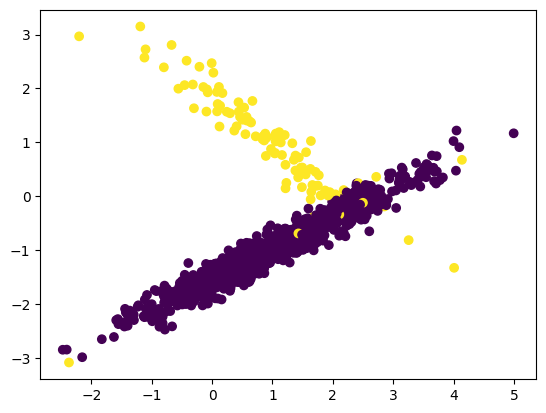

In [ ]:
plt.scatter(final_df['f1'],final_df['f2'], c= final_df['target'])
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversample = SMOTE()
x,y = oversample.fit_resample(x,y)


In [ ]:
x.shape

(1792, 2)

In [ ]:
y.shape

(1792,)

In [ ]:
y[y==0]
len(y[y==0])
len(y[y==1])

896

In [ ]:
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
oversample_df = pd.concat([df1,df2],axis=1)

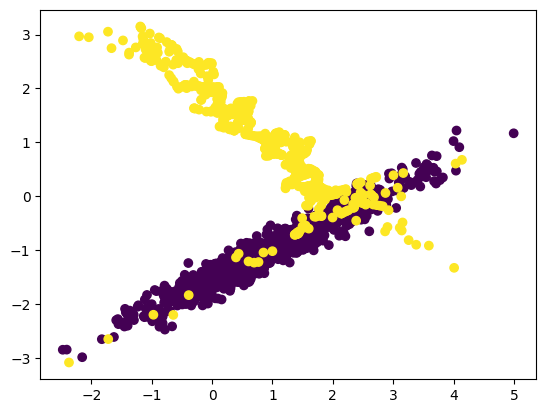

In [ ]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])
plt.show()